> **ARCHIVED — synthetic-data reference (frozen).**
> This is the validated baseline of Approach 1 run end-to-end on *synthetic* `(sequence, spectrum)` data (the hidden `true_spectrum` map). Kept read-only with its executed outputs as a proof-of-correctness reference.
>
> - Executed: 2026-06-24 · model `esm2_t33_650M_UR50D` · env `esm2-design`
> - Active development continues in `guided_design_approach1.ipynb` (real FPbase data).
> - Seeds are fixed, so this notebook is reproducible as-is.


# Approach 1 — Property-guided sequence design (ESM-2 frozen)

Steer ESM-2 650M generation toward a **target spectrum** *without retraining ESM*. The only trained
component is a small **forward model** `g(sequence) -> spectrum` built on frozen ESM-2 embeddings. During
decoding we score each candidate residue by

$$\text{score}(a) = \underbrace{\log p_{\text{ESM}}(a)}_{\text{naturalness}} \;-\; \lambda \cdot \underbrace{\lVert g(s_a) - y_{\text{target}}\rVert^2}_{\text{spectral mismatch}}$$

and only ever consider ESM's **top-k** residues (the "naturalness leash"). This notebook uses **synthetic
(pseudo) paired data** so it runs end-to-end; swap `true_spectrum` / the dataset for real FPBase data later.

Pipeline: load ESM-2 → make pseudo `(sequence, spectrum)` data → train `g` → pseudo-perplexity scorer →
guided refinement loop → candidate pool + Pareto ranking.

## 0. Setup

In [1]:
import math
import numpy as np
import torch
import esm  # fair-esm

try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except Exception:
    HAVE_PLT = False
    print("matplotlib not found - plots skipped (conda install matplotlib)")

MODEL_NAME = "esm2_t33_650M_UR50D"
STANDARD_AA = "ACDEFGHIKLMNPQRSTVWY"
REPR_LAYER, EMBED_DIM = 33, 1280


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = pick_device()
print("device:", DEVICE)

device: mps


In [2]:
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
model = model.eval().to(DEVICE)
for p in model.parameters():
    p.requires_grad_(False)  # ESM-2 is FROZEN in Approach 1 - never trained
batch_converter = alphabet.get_batch_converter()
print("loaded", MODEL_NAME, "(frozen)")

loaded esm2_t33_650M_UR50D (frozen)


In [3]:
def standard_aa_mask(alphabet):
    keep = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
    for aa in STANDARD_AA:
        keep[alphabet.get_idx(aa)] = True
    return keep


AA_MASK = standard_aa_mask(alphabet).to(DEVICE)
SPECIAL_IDX = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}


def to_tokens(seq):
    _, _, toks = batch_converter([("q", seq.strip().upper())])
    return toks.to(DEVICE)


def tokens_to_seq(toks_1d):
    return "".join(alphabet.get_tok(int(t)) for t in toks_1d if int(t) not in SPECIAL_IDX)

## 1. Synthetic (pseudo) paired data

We invent a *hidden* ground-truth map `sequence -> (ex/em spectrum)` driven by amino-acid composition, so a
forward model has a learnable signal and refinement has something to chase. The dataset is built by randomly
mutating a base sequence. **Replace this whole section with your real FPBase pairs later** — everything
downstream only needs `sequences` (list[str]) and `spectra` (N x SPECTRUM_DIM array).

In [4]:
rng = np.random.default_rng(0)

GRID = np.arange(400, 702, 2, dtype=np.float32)   # wavelength grid, 151 points
SPECTRUM_DIM = 2 * len(GRID)                       # excitation + emission concatenated

# Fixed, hidden per-residue coefficients defining the synthetic structure->spectrum map.
AA_COEF  = {a: float(c) for a, c in zip(STANDARD_AA, rng.normal(0, 1, 20))}  # -> ex_max
AA_COEF2 = {a: float(c) for a, c in zip(STANDARD_AA, rng.normal(0, 1, 20))}  # -> Stokes shift
AA_COEF3 = {a: float(c) for a, c in zip(STANDARD_AA, rng.normal(0, 1, 20))}  # -> peak width


def _gaussian(center, sigma):
    return np.exp(-0.5 * ((GRID - center) / sigma) ** 2).astype(np.float32)


def true_spectrum(seq, noise=0.0):
    """Hidden 'ground-truth' ex/em spectrum for a sequence (composition-driven)."""
    seq = seq.upper()
    n = max(len(seq), 1)
    lat1 = sum(AA_COEF.get(a, 0.0) for a in seq) / n
    lat2 = sum(AA_COEF2.get(a, 0.0) for a in seq) / n
    lat3 = sum(AA_COEF3.get(a, 0.0) for a in seq) / n
    ex_max = 450 + 130 / (1 + math.exp(-2.0 * lat1))   # ~450-580 nm
    stokes = 18 + 40 / (1 + math.exp(-2.0 * lat2))     # ~18-58 nm
    ex_sigma = 12 + 14 / (1 + math.exp(-2.0 * lat3))   # ~12-26 nm (peak width varies too)
    em_max = ex_max + stokes
    spec = np.concatenate([_gaussian(ex_max, ex_sigma), _gaussian(em_max, ex_sigma + 5.0)])
    if noise:
        spec = spec + rng.normal(0, noise, spec.shape).astype(np.float32)
    return spec, ex_max, em_max

In [5]:
# Base scaffold (the official ESM example), reused as the refinement start point later.
BASE = "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG"


def random_seq(rng, length, conc):
    """Sequence from a per-sequence Dirichlet composition bias (diverse composition)."""
    probs = rng.dirichlet(np.full(20, conc))
    idx = rng.choice(20, size=length, p=probs)
    return "".join(STANDARD_AA[int(i)] for i in idx)


def mutate(seq, n_mut, rng):
    s = list(seq)
    for _ in range(n_mut):
        s[int(rng.integers(0, len(s)))] = STANDARD_AA[int(rng.integers(0, 20))]
    return "".join(s)


# DIVERSE dataset: varied lengths, varied composition bias, plus some BASE variants.
N = 400
data_rng = np.random.default_rng(1)
sequences, spectra = [], []
for i in range(N):
    if i % 4 == 0:
        s = mutate(BASE, int(data_rng.integers(5, 40)), data_rng)        # near-natural scaffolds
    else:
        length = int(data_rng.integers(50, 121))
        conc = float(10 ** data_rng.uniform(-0.6, 1.0))                  # how peaked composition is
        s = random_seq(data_rng, length, conc)                          # spans full spectral range
    spec, _, _ = true_spectrum(s, noise=0.01)
    sequences.append(s)
    spectra.append(spec)
spectra = np.stack(spectra)

# shuffle so the train/val split is not ordered by generation mode
perm = data_rng.permutation(N)
sequences = [sequences[i] for i in perm]
spectra = spectra[perm]

exs = np.array([true_spectrum(s)[1] for s in sequences])
ems = np.array([true_spectrum(s)[2] for s in sequences])
lens = np.array([len(s) for s in sequences])
print(f"dataset: {N} seqs | length {lens.min()}-{lens.max()} | "
      f"ex_max {exs.min():.0f}-{exs.max():.0f} nm | em_max {ems.min():.0f}-{ems.max():.0f} nm | "
      f"spectrum dim {spectra.shape[1]}")

dataset: 400 seqs | length 50-120 | ex_max 460-549 nm | em_max 499-591 nm | spectrum dim 302


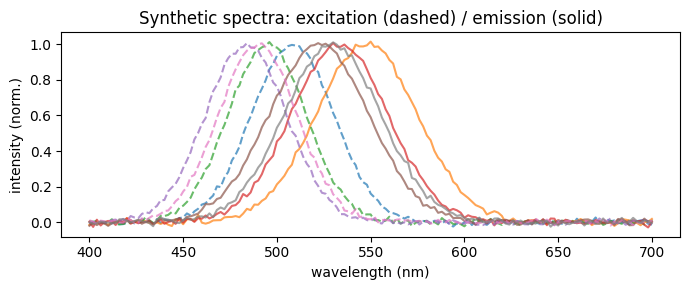

In [6]:
if HAVE_PLT:
    L = len(GRID)
    plt.figure(figsize=(7, 3))
    for k in range(4):
        plt.plot(GRID, spectra[k][:L], "--", alpha=0.7)
        plt.plot(GRID, spectra[k][L:], "-", alpha=0.7)
    plt.xlabel("wavelength (nm)")
    plt.ylabel("intensity (norm.)")
    plt.title("Synthetic spectra: excitation (dashed) / emission (solid)")
    plt.tight_layout()
    plt.show()

## 2. Forward model  `g(sequence) -> spectrum`

The only trained part. Features = **mean-pooled frozen ESM-2 layer-33 embeddings** (dim 1280); head = a
small MLP regressing the spectrum. Because ESM is frozen, we precompute embeddings once and train the MLP
quickly. This model is *also the evaluator* (and is reusable in Approach 2).

In [7]:
@torch.no_grad()
def embed(seqs, batch=16):
    """Mean-pooled frozen ESM-2 layer-33 embeddings: list[str] -> (N, 1280) CPU tensor."""
    out = []
    for i in range(0, len(seqs), batch):
        chunk = seqs[i:i + batch]
        _, _, toks = batch_converter([(f"s{j}", s) for j, s in enumerate(chunk)])
        toks = toks.to(DEVICE)
        reps = model(toks, repr_layers=[REPR_LAYER])["representations"][REPR_LAYER]
        keep = (toks != alphabet.padding_idx) & (toks != alphabet.cls_idx) & (toks != alphabet.eos_idx)
        keep = keep.unsqueeze(-1).float()
        pooled = (reps * keep).sum(1) / keep.sum(1).clamp(min=1)
        out.append(pooled.float().cpu())
    return torch.cat(out, 0)


class ForwardModel(torch.nn.Module):
    def __init__(self, d_in=EMBED_DIM, d_hidden=512, d_out=SPECTRUM_DIM):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(d_in, d_hidden), torch.nn.ReLU(),
            torch.nn.Linear(d_hidden, d_hidden), torch.nn.ReLU(),
            torch.nn.Linear(d_hidden, d_out),
        )

    def forward(self, emb):
        return self.net(emb)

In [8]:
print("embedding dataset with frozen ESM-2 (one-time)...")
X = embed(sequences)
Y = torch.tensor(spectra)
n_val = N // 5
Xtr, Ytr = X[:-n_val].to(DEVICE), Y[:-n_val].to(DEVICE)
Xva, Yva = X[-n_val:].to(DEVICE), Y[-n_val:].to(DEVICE)
print("train", tuple(Xtr.shape), "val", tuple(Xva.shape))

embedding dataset with frozen ESM-2 (one-time)...


train (320, 1280) val (80, 1280)


In [9]:
fwd = ForwardModel().to(DEVICE)
opt = torch.optim.Adam(fwd.parameters(), lr=1e-3)
lossf = torch.nn.MSELoss()
for epoch in range(400):
    fwd.train()
    opt.zero_grad()
    loss = lossf(fwd(Xtr), Ytr)
    loss.backward()
    opt.step()
    if epoch % 50 == 0 or epoch == 399:
        fwd.eval()
        with torch.no_grad():
            vloss = lossf(fwd(Xva), Yva).item()
        print(f"epoch {epoch:3d}  train {loss.item():.4f}  val {vloss:.4f}")

epoch   0  train 0.1417  val 0.1274
epoch  50  train 0.0038  val 0.0036
epoch 100  train 0.0008  val 0.0017


epoch 150  train 0.0004  val 0.0014
epoch 200  train 0.0002  val 0.0013
epoch 250  train 0.0002  val 0.0013


epoch 300  train 0.0001  val 0.0013
epoch 350  train 0.0001  val 0.0012
epoch 399  train 0.0001  val 0.0012


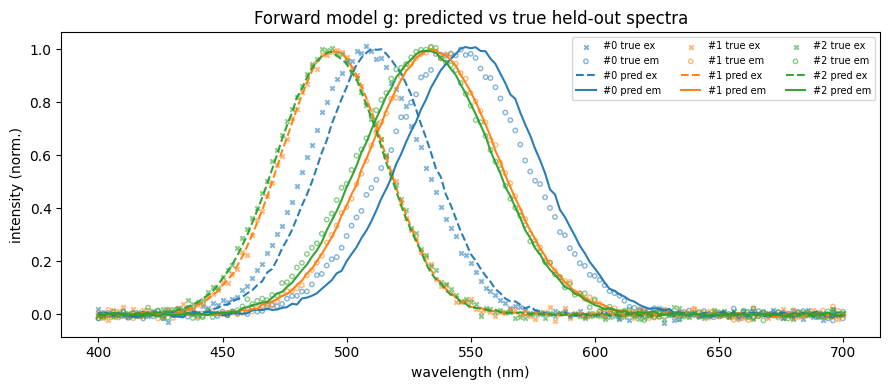

In [10]:
fwd.eval()
if HAVE_PLT:
    n_show = min(3, len(Xva))  # show and label the first 3 held-out examples
    L = len(GRID)

    with torch.no_grad():
        preds = fwd(Xva[:n_show]).cpu().numpy()
    truths = Yva[:n_show].cpu().numpy()

    plt.figure(figsize=(9, 4))
    colors = plt.cm.tab10(np.arange(n_show))

    for i, color in enumerate(colors):
        t = truths[i]
        p = preds[i]

        # Ground truth: scatter points. Prediction: continuous lines.
        plt.scatter(GRID, t[:L], s=10, marker="x", color=color, alpha=0.55, label=f"#{i} true ex")
        plt.scatter(GRID, t[L:], s=10, marker="o", facecolors="none", edgecolors=[color], alpha=0.55, label=f"#{i} true em")
        plt.plot(GRID, p[:L], "--", color=color, alpha=0.95, label=f"#{i} pred ex")
        plt.plot(GRID, p[L:], "-", color=color, alpha=0.95, label=f"#{i} pred em")

    plt.xlabel("wavelength (nm)")
    plt.ylabel("intensity (norm.)")
    plt.title("Forward model g: predicted vs true held-out spectra")
    plt.legend(fontsize=7, ncol=3)
    plt.tight_layout()
    plt.show()

In [11]:
@torch.no_grad()
def g_spectrum(seqs):
    """SURROGATE forward model on raw sequences: str | list[str] -> (N, SPECTRUM_DIM).
    Used for GUIDANCE during design (the only spectrum estimate available at design time)."""
    if isinstance(seqs, str):
        seqs = [seqs]
    return fwd(embed(seqs).to(DEVICE))


def oracle_spectrum(seqs):
    """REAL model output, used ONLY for EVALUATION -- never for guidance.

    Here the 'real model' is the hidden synthetic map true_spectrum(). For real FPbase
    data, replace this with a held-out forward model (NOT the guidance surrogate g) or an
    experimental measurement. Returns (N, SPECTRUM_DIM) on DEVICE.
    """
    if isinstance(seqs, str):
        seqs = [seqs]
    return torch.tensor(np.stack([true_spectrum(s)[0] for s in seqs]), device=DEVICE)

## 3. Pseudo-perplexity (the naturalness metric)

Used for **final ranking**. In the decoding loop we instead use the cheap per-position ESM log-prob
(one forward pass) as the local naturalness term - it is exactly the quantity summed into pseudo-log-likelihood.

In [12]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    _, _, base = batch_converter([("s", seq.strip().upper())])
    base = base[0].to(DEVICE)
    res_pos = [i for i, t in enumerate(base.tolist()) if t not in SPECIAL_IDX]
    total = 0.0
    for s in range(0, len(res_pos), batch_size):
        chunk = res_pos[s:s + batch_size]
        bt = base.unsqueeze(0).repeat(len(chunk), 1).clone()
        for r, pos in enumerate(chunk):
            bt[r, pos] = alphabet.mask_idx
        lp = torch.log_softmax(model(bt)["logits"], dim=-1)
        for r, pos in enumerate(chunk):
            total += float(lp[r, pos, base[pos]])
    n = len(res_pos)
    return total, math.exp(-total / n)

## 4. Guided refinement loop

Refine a **complete** sequence (so `g` always sees a valid input). For each editable position: mask it, get
ESM's top-k residues (naturalness leash), tentatively fill each, score with
`z(log p_ESM(a)) - lambda * z(spectral_error)` (both standardized within the top-k, so the trade-off is scale-free), and commit the best. Sweep until the budget is spent.
The `k` candidate `g`-evaluations are batched into a single forward pass.

> **Guidance vs. evaluation.** Candidate scoring inside the loop uses the *surrogate* `g` (all you have at design time). But every *evaluation* below -- the sweep trace, the demo errors, and the pool ranking -- uses `oracle_spectrum`, the **real model output** (the hidden `true_spectrum` here; a held-out forward model or assay for real data). Grading a design with the same `g` that guided it is circular and optimistically biased.

In [13]:
@torch.no_grad()
def guided_refine(seq, target_spectrum, n_sweeps=3, k=10, lam=3.0,
                  temperature=0.0, editable=None, eval_fn=None, verbose=True):
    """Refine a complete sequence toward target_spectrum while staying natural.

    GUIDANCE always uses the surrogate g (g_spectrum) -- it is the only spectrum estimate
    available at design time. EVALUATION of progress (the returned trace) uses `eval_fn`
    when supplied -- pass oracle_spectrum (the REAL model output) so we never grade a
    design with the same surrogate that guided it (which is circular / optimistic).

    target_spectrum: (SPECTRUM_DIM,) tensor on DEVICE.
    editable: list of residue indices (0-based over residues) allowed to change; None = all.
    Returns (refined_seq, trace_of_normalized_errors).

    Scoring: within ESM's top-k candidates at each position we STANDARDIZE both the
    naturalness term log p_ESM and the surrogate spectral-error term d, then combine as
    z(log p_ESM) - lam * z(d). Standardizing makes the trade-off scale-free.
    """
    toks = to_tokens(seq)
    res_pos = [i for i, t in enumerate(toks[0].tolist()) if t not in SPECIAL_IDX]
    if editable is not None:
        res_pos = [res_pos[j] for j in editable]
    tnorm = float(torch.sum(target_spectrum ** 2)) + 1e-8
    trace = []
    for sweep in range(n_sweeps):
        for pos in res_pos:
            toks[0, pos] = alphabet.mask_idx                       # (a) mask
            logits = model(toks)["logits"][0, pos]
            logits = logits.masked_fill(~AA_MASK, float("-inf"))
            logp = torch.log_softmax(logits, dim=-1)
            topv, topi = torch.topk(logp, k)                       # (b) ESM top-k = naturalness leash
            cand_seqs = []
            for idx in topi.tolist():
                toks[0, pos] = idx                                 # tentative fill -> complete seq
                cand_seqs.append(tokens_to_seq(toks[0]))
            preds = g_spectrum(cand_seqs)                          # (c) GUIDANCE: surrogate g
            d = torch.sum((preds - target_spectrum.unsqueeze(0)) ** 2, dim=1) / tnorm
            lp_z = (topv - topv.mean()) / (topv.std() + 1e-6)      # standardize within top-k
            d_z = (d - d.mean()) / (d.std() + 1e-6)
            scores = lp_z - lam * d_z                              #     scale-free trade-off
            if temperature and temperature > 0:
                choice = torch.multinomial(torch.softmax(scores / temperature, -1), 1).item()
            else:
                choice = int(torch.argmax(scores))
            toks[0, pos] = int(topi[choice].item())                # (d) commit
        cur = tokens_to_seq(toks[0])
        ev = eval_fn(cur)[0] if eval_fn is not None else g_spectrum(cur)[0]   # EVALUATION
        err = float(torch.sum((ev - target_spectrum) ** 2) / tnorm)
        trace.append(err)
        if verbose:
            tag = "real" if eval_fn is not None else "surrogate"
            print(f"sweep {sweep}: normalized spectral error ({tag}) {err:.4f}")
    return tokens_to_seq(toks[0]), trace

In [14]:
@torch.no_grad()
def explain_guided_design_step(seq=BASE, target_spectrum=None, residue_index=10, k=5, lam=3.0):
    """
    Walk through one position of the guided refinement loop.

    Shows:
    1. input sequence + target spectrum
    2. tokenization
    3. masking one residue
    4. ESM top-k amino acid suggestions
    5. candidate sequence construction
    6. predicted spectra from g
    7. combined ESM/spectral score
    8. chosen output sequence after one committed mutation
    """

    def show_window(s, i, radius=10):
        start = max(0, i - radius)
        end = min(len(s), i + radius + 1)
        return f"{start}:{end}  {s[start:i]}[{s[i]}]{s[i+1:end]}"

    if target_spectrum is None:
        # Reuse target_spec if Section 5 has already defined it.
        # Otherwise create a synthetic target spectrum for demonstration.
        if "target_spec" in globals():
            target_spectrum = target_spec
        else:
            hidden_truth = random_seq(np.random.default_rng(12345), len(BASE), conc=1.2)
            tspec_np, ex_t, em_t = true_spectrum(hidden_truth)
            target_spectrum = torch.tensor(tspec_np, device=DEVICE)
            print(f"Created demo target spectrum: ex_max~{ex_t:.0f} nm, em_max~{em_t:.0f} nm")

    target_spectrum = target_spectrum.to(DEVICE)

    print("STEP 0: Inputs")
    print("sequence length:", len(seq))
    print("chosen residue index:", residue_index)
    print("sequence window:", show_window(seq, residue_index))
    print("target spectrum shape:", tuple(target_spectrum.shape))
    print("target spectrum first 8 values:", target_spectrum[:8].detach().cpu().numpy())
    print()

    print("STEP 1: Convert sequence to ESM tokens")
    toks = to_tokens(seq)
    res_pos = [i for i, t in enumerate(toks[0].tolist()) if t not in SPECIAL_IDX]
    token_pos = res_pos[residue_index]
    original_token = int(toks[0, token_pos].item())
    original_aa = alphabet.get_tok(original_token)

    print("token tensor shape:", tuple(toks.shape))
    print("residue index in protein sequence:", residue_index)
    print("corresponding token position in ESM input:", token_pos)
    print("original amino acid:", original_aa)
    print()

    print("STEP 2: Mask this residue")
    masked_toks = toks.clone()
    masked_toks[0, token_pos] = alphabet.mask_idx

    masked_view = seq[:residue_index] + "*" + seq[residue_index + 1:]
    print("masked sequence window:", show_window(masked_view, residue_index))
    print("input to ESM is the same sequence, but this position is replaced by <mask>")
    print()

    print("STEP 3: Ask ESM which amino acids naturally fit here")
    logits = model(masked_toks)["logits"][0, token_pos]
    logits = logits.masked_fill(~AA_MASK, float("-inf"))
    logp = torch.log_softmax(logits, dim=-1)
    topv, topi = torch.topk(logp, k)

    print(f"Top {k} ESM candidates:")
    for rank, (lp, idx) in enumerate(zip(topv, topi), start=1):
        aa = alphabet.get_tok(int(idx.item()))
        print(f"  rank {rank}: amino acid={aa}, log p_ESM={float(lp):.4f}")
    print()

    print("STEP 4: Build complete candidate sequences")
    cand_seqs = []
    cand_aas = []

    for idx in topi.tolist():
        aa = alphabet.get_tok(int(idx))
        cand = seq[:residue_index] + aa + seq[residue_index + 1:]
        cand_seqs.append(cand)
        cand_aas.append(aa)

    for aa, cand in zip(cand_aas, cand_seqs):
        print(f"  candidate {aa}: {show_window(cand, residue_index)}")
    print()

    print("STEP 5: Predict each candidate's spectrum using g (GUIDANCE surrogate, not evaluation)")
    preds = g_spectrum(cand_seqs)
    print("predicted spectra shape:", tuple(preds.shape))
    print("meaning: one predicted spectrum for each candidate sequence")
    print()

    print("STEP 6: Compute spectral error for each candidate")
    tnorm = float(torch.sum(target_spectrum ** 2)) + 1e-8
    d = torch.sum((preds - target_spectrum.unsqueeze(0)) ** 2, dim=1) / tnorm

    for aa, err in zip(cand_aas, d):
        print(f"  candidate {aa}: normalized spectral error={float(err):.6f}")
    print()

    print("STEP 7: Combine ESM naturalness and spectral match")
    lp_z = (topv - topv.mean()) / (topv.std(unbiased=False) + 1e-6)
    d_z = (d - d.mean()) / (d.std(unbiased=False) + 1e-6)
    scores = lp_z - lam * d_z

    print("score = z(log p_ESM) - lam * z(spectral_error)")
    print("lam:", lam)
    print()

    for aa, lp, err, lpzi, dzi, score in zip(cand_aas, topv, d, lp_z, d_z, scores):
        print(
            f"  {aa}: "
            f"logp={float(lp): .4f}, "
            f"err={float(err): .6f}, "
            f"z_logp={float(lpzi): .3f}, "
            f"z_err={float(dzi): .3f}, "
            f"final_score={float(score): .3f}"
        )
    print()

    print("STEP 8: Commit the best candidate")
    choice = int(torch.argmax(scores))
    chosen_aa = cand_aas[choice]
    refined_once = cand_seqs[choice]

    print("chosen amino acid:", chosen_aa)
    print("before:", show_window(seq, residue_index))
    print("after: ", show_window(refined_once, residue_index))
    print()

    return {
        "input_sequence": seq,
        "residue_index": residue_index,
        "original_aa": original_aa,
        "chosen_aa": chosen_aa,
        "output_sequence_after_one_step": refined_once,
        "candidate_aas": cand_aas,
        "candidate_errors": d.detach().cpu(),
        "candidate_scores": scores.detach().cpu(),
    }


step_output = explain_guided_design_step(
    seq=BASE,
    residue_index=10,
    k=5,
    lam=3.0,
)

Created demo target spectrum: ex_max~498 nm, em_max~533 nm
STEP 0: Inputs
sequence length: 65
chosen residue index: 10
sequence window: 0:21  MKTVRQERLK[S]IVRILERSKE
target spectrum shape: (302,)
target spectrum first 8 values: [0.00035248 0.00048612 0.00066599 0.00090638 0.00122538 0.00164571
 0.0021956  0.00290987]

STEP 1: Convert sequence to ESM tokens
token tensor shape: (1, 67)
residue index in protein sequence: 10
corresponding token position in ESM input: 11
original amino acid: S

STEP 2: Mask this residue
masked sequence window: 0:21  MKTVRQERLK[*]IVRILERSKE
input to ESM is the same sequence, but this position is replaced by <mask>

STEP 3: Ask ESM which amino acids naturally fit here
Top 5 ESM candidates:
  rank 1: amino acid=E, log p_ESM=-1.2953
  rank 2: amino acid=R, log p_ESM=-2.0712
  rank 3: amino acid=Q, log p_ESM=-2.2404
  rank 4: amino acid=K, log p_ESM=-2.2598
  rank 5: amino acid=A, log p_ESM=-2.2850

STEP 4: Build complete candidate sequences
  candidate E: 0:21 

predicted spectra shape: (5, 302)
meaning: one predicted spectrum for each candidate sequence

STEP 6: Compute spectral error for each candidate
  candidate E: normalized spectral error=0.019590
  candidate R: normalized spectral error=0.027187
  candidate Q: normalized spectral error=0.018947
  candidate K: normalized spectral error=0.022756
  candidate A: normalized spectral error=0.020643

STEP 7: Combine ESM naturalness and spectral match
score = z(log p_ESM) - lam * z(spectral_error)
lam: 3.0

  E: logp=-1.2953, err= 0.019590, z_logp= 1.959, z_err=-0.750, final_score= 4.211
  R: logp=-2.0712, err= 0.027187, z_logp=-0.109, z_err= 1.801, final_score=-5.512
  Q: logp=-2.2404, err= 0.018947, z_logp=-0.560, z_err=-0.967, final_score= 2.340
  K: logp=-2.2598, err= 0.022756, z_logp=-0.612, z_err= 0.313, final_score=-1.550
  A: logp=-2.2850, err= 0.020643, z_logp=-0.679, z_err=-0.397, final_score= 0.512

STEP 8: Commit the best candidate
chosen amino acid: E
before: 0:21  MKTVRQERLK[S]IVR

## 5. Demo: design toward a held-out target spectrum

Pick a held-out (validation) sequence, take its *spectrum* as the design target (we pretend its sequence is
unknown), draft from `BASE`, and refine toward that spectrum.

In [15]:
# Target = spectrum of a fresh, held-out sequence the SAME length as BASE (identity well-defined).
# We pretend its sequence is unknown and only observe its (REAL) spectrum.
hidden_truth = random_seq(np.random.default_rng(12345), len(BASE), conc=1.2)
tspec_np, ex_t, em_t = true_spectrum(hidden_truth)
target_spec = torch.tensor(tspec_np, device=DEVICE)
print(f"target spectrum: ex_max~{ex_t:.0f} nm, em_max~{em_t:.0f} nm")

tnorm = float(torch.sum(target_spec ** 2)) + 1e-8


def real_err(seq):       # EVALUATION: real model output
    return float(torch.sum((oracle_spectrum(seq)[0] - target_spec) ** 2) / tnorm)


def surrogate_err(seq):  # surrogate g, shown only for contrast
    return float(torch.sum((g_spectrum(seq)[0] - target_spec) ** 2) / tnorm)


print(f"draft (BASE) spectral error  REAL: {real_err(BASE):.4f}   (surrogate g: {surrogate_err(BASE):.4f})")

# guidance uses surrogate g; eval_fn=oracle_spectrum reports the REAL error each sweep
refined, trace = guided_refine(BASE, target_spec, n_sweeps=3, k=10, lam=3.0,
                               eval_fn=oracle_spectrum)
print("\nrefined:", refined)
ident = sum(a == b for a, b in zip(refined, hidden_truth)) / len(hidden_truth)
_, ppl = pseudo_perplexity(refined)
print(f"refined spectral error       REAL: {real_err(refined):.4f}   (surrogate g: {surrogate_err(refined):.4f})")
print(f"identity to hidden ground-truth: {ident:.3f}   pseudo-perplexity: {ppl:.3f}")

target spectrum: ex_max~498 nm, em_max~533 nm
draft (BASE) spectral error  REAL: 0.0203   (surrogate g: 0.0224)


sweep 0: normalized spectral error (real) 0.0002


sweep 1: normalized spectral error (real) 0.0025


sweep 2: normalized spectral error (real) 0.0051

refined: MIKIGEERKKKIISILKKSKKPLSGKELAEILGVSREIIRSDIYYLRSKGIKIISTPKGYLLIEE


refined spectral error       REAL: 0.0051   (surrogate g: 0.0014)
identity to hidden ground-truth: 0.092   pseudo-perplexity: 2.984


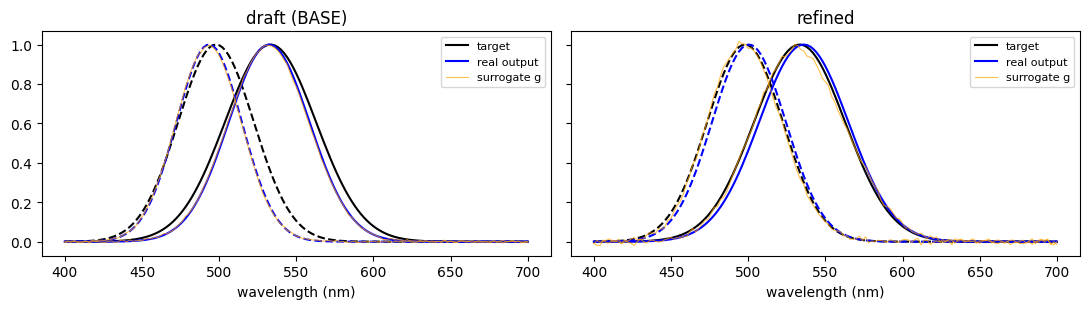

In [16]:
if HAVE_PLT:
    L = len(GRID)
    t = target_spec.cpu().numpy()
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
    for a, (seq, title) in zip(ax, [(BASE, "draft (BASE)"), (refined, "refined")]):
        real = oracle_spectrum(seq)[0].cpu().numpy()   # REAL output (evaluation)
        surr = g_spectrum(seq)[0].cpu().numpy()         # surrogate g (guidance), for contrast
        a.plot(GRID, t[:L], "k--"); a.plot(GRID, t[L:], "k-", label="target")
        a.plot(GRID, real[:L], "b--"); a.plot(GRID, real[L:], "b-", label="real output")
        a.plot(GRID, surr[:L], color="orange", lw=0.8, alpha=0.7)
        a.plot(GRID, surr[L:], color="orange", lw=0.8, alpha=0.7, label="surrogate g")
        a.set_title(title); a.set_xlabel("wavelength (nm)"); a.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 6. Candidate pool + Pareto ranking

Sweep `lambda` (and a little sampling temperature) to build a pool, then trade off **naturalness**
(pseudo-perplexity) against **on-target** (spectral error). `lambda=0` ignores the spectrum (pure ESM);
large `lambda` chases the spectrum harder at some cost to naturalness.

> Runtime note: cost is dominated by ESM-2 forward passes inside refinement. Reduce `n_sweeps`, `k`, the
> pool size, or pass an `editable` subset of positions to speed this up.

In [17]:
pool = []
for lam in [0.0, 1.0, 3.0, 10.0]:
    for seed in range(2):
        torch.manual_seed(seed)
        temp = 0.0 if seed == 0 else 0.8
        s, _ = guided_refine(BASE, target_spec, n_sweeps=2, k=10, lam=lam,
                             temperature=temp, verbose=False)
        err_real = float(torch.sum((oracle_spectrum(s)[0] - target_spec) ** 2) / tnorm)  # EVALUATION
        err_surr = float(torch.sum((g_spectrum(s)[0] - target_spec) ** 2) / tnorm)        # surrogate (contrast)
        _, ppl = pseudo_perplexity(s)
        pool.append({"lam": lam, "seed": seed, "seq": s,
                     "err_real": err_real, "err_surr": err_surr, "ppl": ppl})
        print(f"lam={lam:5.1f} seed={seed} temp={temp:.1f}  "
              f"err_REAL={err_real:.4f}  err_surr={err_surr:.4f}  ppl={ppl:.3f}")

lam=  0.0 seed=0 temp=0.0  err_REAL=0.0357  err_surr=0.0420  ppl=1.916


lam=  0.0 seed=1 temp=0.8  err_REAL=0.0363  err_surr=0.0216  ppl=7.392


lam=  1.0 seed=0 temp=0.0  err_REAL=0.0002  err_surr=0.0029  ppl=3.841


lam=  1.0 seed=1 temp=0.8  err_REAL=0.0066  err_surr=0.0016  ppl=4.411


lam=  3.0 seed=0 temp=0.0  err_REAL=0.0025  err_surr=0.0012  ppl=3.057


lam=  3.0 seed=1 temp=0.8  err_REAL=0.0231  err_surr=0.0017  ppl=7.711


lam= 10.0 seed=0 temp=0.0  err_REAL=0.0021  err_surr=0.0007  ppl=5.458


lam= 10.0 seed=1 temp=0.8  err_REAL=0.0012  err_surr=0.0007  ppl=9.584


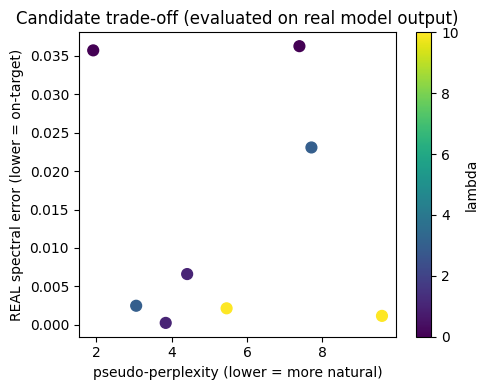

best candidate: IKILKEEQQKEILKILKKSKKPVSGSELSKKIGVTRQVIVGNIKALKEKGYEIISTPKGYILKKK
  lam=1.0  err_REAL=0.0002  (surrogate 0.0029)  ppl=3.841


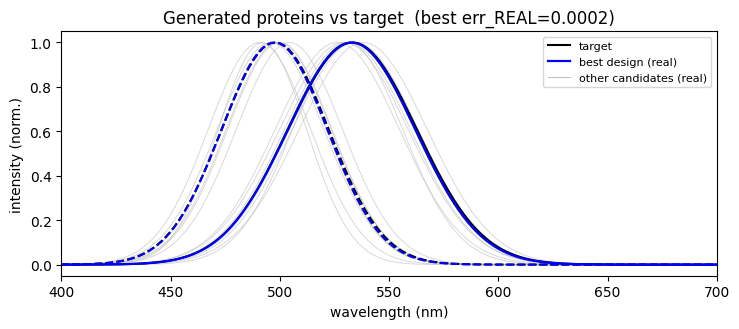

In [18]:
if HAVE_PLT:
    plt.figure(figsize=(5, 4))
    sc = plt.scatter([c["ppl"] for c in pool], [c["err_real"] for c in pool],
                     c=[c["lam"] for c in pool], cmap="viridis", s=60)
    plt.colorbar(sc, label="lambda")
    plt.xlabel("pseudo-perplexity (lower = more natural)")
    plt.ylabel("REAL spectral error (lower = on-target)")
    plt.title("Candidate trade-off (evaluated on real model output)")
    plt.tight_layout()
    plt.show()

# Pareto-ish pick: lowest REAL spectral error among the more-natural half.
natural = sorted(pool, key=lambda c: c["ppl"])[:max(1, len(pool) // 2)]
best = min(natural, key=lambda c: c["err_real"])
print("best candidate:", best["seq"])
print(f"  lam={best['lam']}  err_REAL={best['err_real']:.4f}  (surrogate {best['err_surr']:.4f})  ppl={best['ppl']:.3f}")

# Spectra of the GENERATED proteins vs the target (real model output).
# Target: black. Best design: blue. Other pool candidates: faint grey. (ex dashed, em solid)
if HAVE_PLT:
    L = len(GRID)
    t = target_spec.cpu().numpy()
    plt.figure(figsize=(7.5, 3.4))
    for c in pool:
        if c is best:
            continue
        r = oracle_spectrum(c["seq"])[0].cpu().numpy()
        plt.plot(GRID, r[:L], color="0.75", lw=0.7, alpha=0.6)
        plt.plot(GRID, r[L:], color="0.75", lw=0.7, alpha=0.6)
    rb = oracle_spectrum(best["seq"])[0].cpu().numpy()
    plt.plot(GRID, t[:L], "k--"); plt.plot(GRID, t[L:], "k-", label="target")
    plt.plot(GRID, rb[:L], "b--"); plt.plot(GRID, rb[L:], "b-", lw=1.6, label="best design (real)")
    plt.plot([], [], color="0.75", lw=0.7, label="other candidates (real)")
    plt.xlabel("wavelength (nm)"); plt.ylabel("intensity (norm.)")
    plt.title(f"Generated proteins vs target  (best err_REAL={best['err_real']:.4f})")
    plt.legend(fontsize=8); plt.xlim(GRID[0], GRID[-1]); plt.tight_layout(); plt.show()

## Notes & next steps

- **Swap in real data:** replace Section 1 so `sequences` / `spectra` come from your FPBase pairs; resample
  real ex/em curves onto `GRID`. Nothing else changes. Split by sequence identity (not randomly) to measure
  true generalization.
- **`lambda` is the steering knob:** sweep it on a log grid and read the Pareto front; pick the knee.
- **`editable` positions:** restrict refinement to plausible spectral-tuning residues to save compute and
  avoid disrupting the fold scaffold.
- **Limitation (by design):** guidance is inference-time only - ESM's prior dominates, and per-position
  re-ranking can miss changes that require *coordinated* multi-residue edits. If the target needs a large
  spectral shift, graduate to **Approach 2** (FiLM adaptor + conditional MLM), reusing this `g` for evaluation.
- **Exact recovery vs. property match:** identity to the hidden ground truth will usually be modest - many
  sequences map to the same spectrum. The goal is matching the *spectrum*, not reproducing the exact sequence.